# S2_Exploración y perfilado

### Librerias y carga del dataset

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('NovaMarket_datos_crudos.csv')
df.head()

,id_pedido,id_cliente,fecha_compra,canal,ciudad,codigo_postal,categoria_producto,producto,precio,unidades,edad_cliente,correo,nivel_satisfaccion,fecha_actualizacion_stock
0,P00383,C0276,2026-01-03,App,Bucaramanga,68001,Belleza,Camiseta,-1742611.0,4,-19,c0276gmail.com,alto,2026-07-01
1,P00403,C0167,6/12/2026,Web,Cali,76001,Deportes,Cafetera,1828583.0,2,23,c0167@hotmail.com,MEDIO,2026-07-01
2,P00403,C0167,6/12/2026,Web,Cali,76001,Deportes,Cafetera,1828583.0,2,23,c0167@hotmail.com,MEDIO,2026-07-01
3,P00450,C0128,07/09/2026,App,bucaramanga,68001,electronica,Set bloques,787178.0,6,69,c0128@hotmail.com,MEDIO,2026-07-15
4,P00449,C0304,2025-07-19,Tienda,Bogotá,8001,Belleza,Audífonos BT,357231.0,5,67,c0304@novamarket.co,Bajo,2026-05-20


## Información general dataset

In [28]:
df.info()
df.shape
df.head

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 620 entries, 0 to 619
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_pedido                  620 non-null    object 
 1   id_cliente                 620 non-null    object 
 2   fecha_compra               620 non-null    object 
 3   canal                      620 non-null    object 
 4   ciudad                     589 non-null    object 
 5   codigo_postal              620 non-null    int64  
 6   categoria_producto         620 non-null    object 
 7   producto                   620 non-null    object 
 8   precio                     599 non-null    float64
 9   unidades                   620 non-null    int64  
 10  edad_cliente               620 non-null    int64  
 11  correo                     516 non-null    object 
 12  nivel_satisfaccion         574 non-null    object 
 13  fecha_actualizacion_stock  620 non-null    object 

<bound method NDFrame.head of     id_pedido id_cliente fecha_compra   canal       ciudad  codigo_postal  \
0      P00383      C0276   2026-01-03     App  Bucaramanga          68001   
1      P00403      C0167    6/12/2026     Web         Cali          76001   
2      P00403      C0167    6/12/2026     Web         Cali          76001   
3      P00450      C0128   07/09/2026     App  bucaramanga          68001   
4      P00449      C0304   2025-07-19  Tienda       Bogotá           8001   
..        ...        ...          ...     ...          ...            ...   
615    P00220      C0288   2026-07-27  Tienda          NaN          68001   
616    P00306      C0299   03/01/2025  Tienda  Bogotá D.C.          11001   
617    P00584      C0199   11/11/2025     App       BOGOTÁ          11001   
618    P00205      C0323   26/03/2025     App  Bucaramanga          68001   
619    P00211      C0292   20/09/2025     App  Bucaramanga          68001   

    categoria_producto      producto     prec

## Valores Faltantes

In [29]:
faltantes = pd.DataFrame({
    "Cantidad": df.isnull().sum(),
    "Porcentaje (%)": (df.isnull().mean()*100).round(2)
})

faltantes

,Cantidad,Porcentaje (%)
id_pedido,0,0.00
id_cliente,0,0.00
fecha_compra,0,0.00
canal,0,0.00
ciudad,31,5.00
codigo_postal,0,0.00
categoria_producto,0,0.00
producto,0,0.00
precio,21,3.39
unidades,0,0.00


## Histograma 

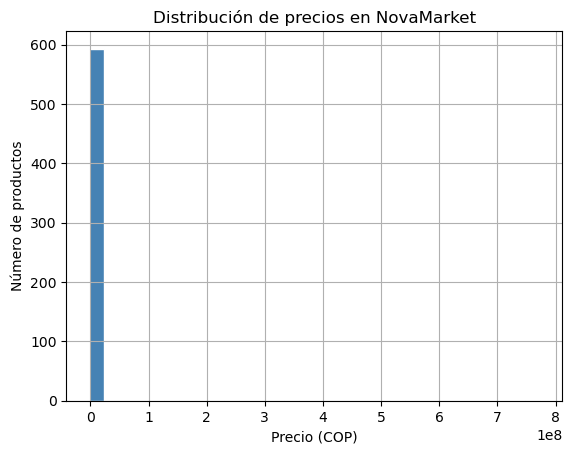

In [13]:
# Histograma de la columna precio del dataset NovaMarket
df['precio'].hist(bins=30, color='steelblue', edgecolor='white')
plt.title('Distribución de precios en NovaMarket')
plt.xlabel('Precio (COP)')
plt.ylabel('Número de productos')
plt.show()

In [4]:
df.describe()

,codigo_postal,precio,unidades,edad_cliente
count,620.000000,5.990000e+02,620.000000,620.000000
mean,31917.129032,4.888703e+06,188.682258,48.012903
std,30339.586863,4.292512e+07,1240.652475,28.668511
min,5001.000000,-2.448455e+06,-3.000000,-20.000000
25%,8001.000000,5.914020e+05,2.000000,31.000000
50%,13001.000000,1.178666e+06,3.000000,46.000000
75%,68001.000000,1.856670e+06,5.000000,63.000000
max,76001.000000,7.730038e+08,9999.000000,200.000000


In [ ]:
## Valores únicos

In [30]:
df.nunique()

id_pedido                    600
id_cliente                   311
fecha_compra                 495
canal                          3
ciudad                        19
codigo_postal                  6
categoria_producto            17
producto                      14
precio                       579
unidades                      12
edad_cliente                  71
correo                       429
nivel_satisfaccion             8
fecha_actualizacion_stock      8
dtype: int64

In [ ]:
## Perfilado de cada variable

In [31]:
for columna in df.columns:

    print(f"VARIABLE: {columna}")

    print("Tipo:", df[columna].dtype)

    print(f"Faltantes: {df[columna].isna().mean()*100:.2f}%")

    if pd.api.types.is_numeric_dtype(df[columna]):

        print("\nEstadísticos descriptivos")

        print(df[columna].describe())

    else:

        print("\nFrecuencias")

        print(df[columna].value_counts())

        print("\nCardinalidad:", df[columna].nunique())

    print("\n")

VARIABLE: id_pedido
Tipo: object
Faltantes: 0.00%

Frecuencias
id_pedido
P00263    2
P00030    2
P00207    2
P00110    2
P00190    2
         ..
P00220    1
P00306    1
P00584    1
P00205    1
P00148    1
Name: count, Length: 600, dtype: int64

Cardinalidad: 600


VARIABLE: id_cliente
Tipo: object
Faltantes: 0.00%

Frecuencias
id_cliente
C0043    6
C0165    5
C0039    5
C0186    5
C0012    5
        ..
C0207    1
C0055    1
C0250    1
C0128    1
C0323    1
Name: count, Length: 311, dtype: int64

Cardinalidad: 311


VARIABLE: fecha_compra
Tipo: object
Faltantes: 0.00%

Frecuencias
fecha_compra
15/11/2027    9
2027-05-20    8
00/00/2026    8
2026-13-05    6
31/04/2026    5
             ..
2026-11-04    1
15/04/2025    1
2026-08-16    1
03/06/2026    1
06/03/2026    1
Name: count, Length: 495, dtype: int64

Cardinalidad: 495


VARIABLE: canal
Tipo: object
Faltantes: 0.00%

Frecuencias
canal
Tienda    224
App       218
Web       178
Name: count, dtype: int64

Cardinalidad: 3


VARIABLE: ci

## Histograma

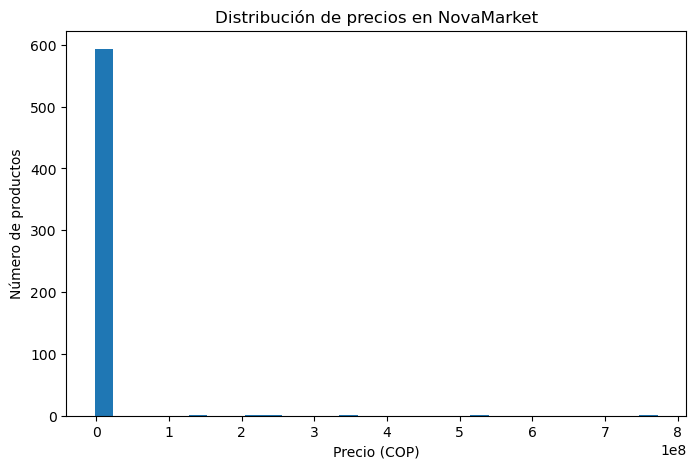

In [32]:
plt.figure(figsize=(8,5))

plt.hist(df["precio"], bins=30)

plt.title("Distribución de precios en NovaMarket")

plt.xlabel("Precio (COP)")
plt.ylabel("Número de productos")

plt.show()

### Interpretación del histograma

Se compararon histogramas con diferentes cantidades de intervalos (bins = 5, 30 y 100).

- Con **5 bins**, la distribución pierde mucho detalle al agrupar demasiados valores.
- Con **30 bins**, se obtiene un equilibrio entre detalle y claridad, por lo que es una opción adecuada para el análisis.
- Con **100 bins**, el histograma presenta un nivel de detalle excesivo y resulta más difícil de interpretar.

En los tres casos se observa que la mayoría de los productos se concentran en precios relativamente bajos, mientras que unos pocos valores extremadamente altos (outliers) expanden la escala del eje X y comprimen la distribución principal.

## Histograma comparando bins

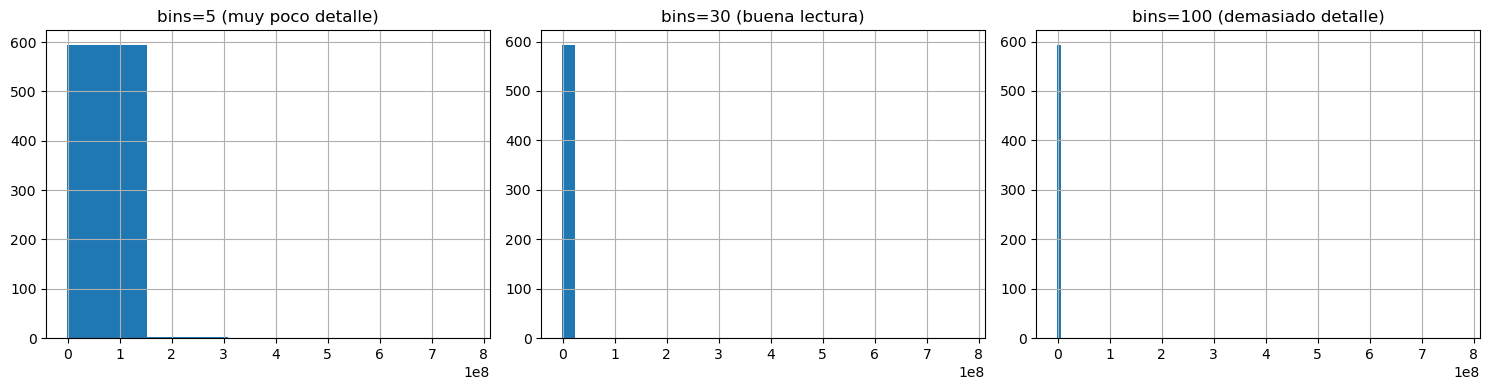

In [3]:
# Comparar el mismo dato con distinto número de bins
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['precio'].hist(bins=5,   ax=axes[0]); axes[0].set_title('bins=5 (muy poco detalle)')
df['precio'].hist(bins=30,  ax=axes[1]); axes[1].set_title('bins=30 (buena lectura)')
df['precio'].hist(bins=100, ax=axes[2]); axes[2].set_title('bins=100 (demasiado detalle)')

plt.tight_layout()
plt.show()

## Boxplot

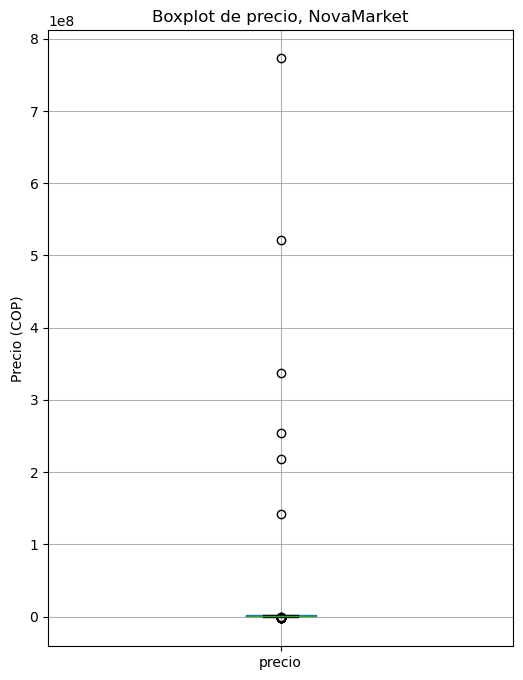

In [18]:
# Boxplot de una sola columna del dataset NovaMarket
df.boxplot(column='precio', vert=True, figsize=(6, 8))
plt.title('Boxplot de precio, NovaMarket')
plt.ylabel('Precio (COP)')
plt.show()

### Interpretación del boxplot

El boxplot muestra claramente la presencia de valores atípicos (outliers) en la variable `precio`.

La mayor parte de los productos se concentra en un rango de precios relativamente bajo; sin embargo, existen varios registros con precios muy superiores al resto, alcanzando aproximadamente 773 millones de COP.

Estos valores extremos influyen en la media, aumentan la dispersión de los datos y dificultan la visualización de la distribución mediante el histograma.

# Boxplot variables numéricas

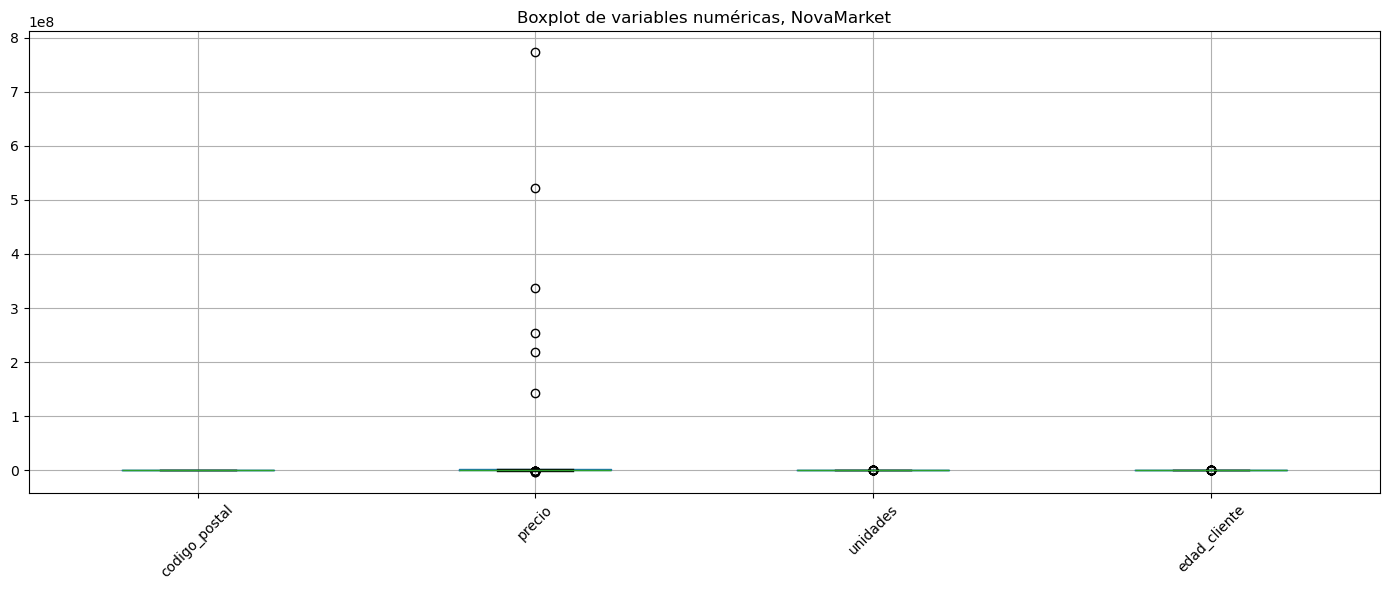

In [15]:
# Boxplot de todas las variables numéricas a la vez
columnas_numericas = df.select_dtypes(include='number').columns.tolist()
df[columnas_numericas].boxplot(figsize=(14, 6), rot=45)
plt.title('Boxplot de variables numéricas, NovaMarket')
plt.tight_layout()
plt.show()

## Simetría y sesgo (skewness)

In [19]:
# Método 1: comparar media y mediana (rápido, sin fórmulas)
media = df['precio'].mean()
mediana = df['precio'].median()

if media > mediana:
    print(f"Sesgo positivo (a la derecha). Media: {media:.2f} | Mediana: {mediana:.2f}")
elif media < mediana:
    print(f"Sesgo negativo (a la izquierda). Media: {media:.2f} | Mediana: {mediana:.2f}")
else:
    print("Distribución aproximadamente simétrica.")

# Método 2: coeficiente de asimetría (skewness), un solo número
print(f"Skewness de precio: {df['precio'].skew():.2f}")

Sesgo positivo (a la derecha). Media: 4888703.29 | Mediana: 1178666.00
Skewness de precio: 13.90


# Señales de alerta

Durante el perfilado del dataset NovaMarket se identificaron los siguientes aspectos:

- Se detectan valores atípicos (outliers) en la variable `precio`.
- El precio máximo registrado es aproximadamente **773 millones de COP**, muy superior al resto de observaciones.
- Existen precios negativos, los cuales deben revisarse porque un precio menor que cero normalmente no es válido.
- Los valores extremos afectan la media, la desviación estándar y la visualización del histograma.
- Se recomienda revisar la calidad de estos registros antes de realizar el preprocesamiento y el entrenamiento de modelos.
- Verificar si existen valores faltantes según el reporte generado.

# Conclusión

El análisis exploratorio permitió conocer la estructura y calidad inicial del dataset NovaMarket. Se identificaron valores atípicos importantes en la variable `precio`, incluyendo registros con precios extremadamente altos y algunos precios negativos que deberán revisarse durante el preprocesamiento. Asimismo, el perfilado de las variables proporciona una base para las siguientes etapas de limpieza, transformación y modelado de los datos.